In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report

In [21]:
# 1.Load fashion MINST dataset

X, y  = fetch_openml('Fashion-MNIST',version=1,as_frame=False,return_X_y=True)
#Convert pixel values to float
X = X.astype('float32')

#Convert pixel values to int 
y = y.astype('int')
print("Dataset Shape: ",X.shape)

Dataset Shape:  (70000, 784)


In [22]:
X = X[:1000]
y = y[:1000]

In [24]:
#2. Use a smaller dataset for faster execution

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state= 42
)
print(f"Training Samples:{X_train.shape[0]}")
print(f"Testing Samples:{X_test.shape[0]}")

Training Samples:800
Testing Samples:200


In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
print("\nTraining Linear SVM....")
linear_svm = SVC(kernel='linear')

linear_svm.fit(X_train,y_train)

y_pred_linear = linear_svm.predict(X_test)

linear_accuracy = accuracy_score(y_test, y_pred_linear)

print("Linear SVM Accuracy:",linear_accuracy * 100, "%")


Training Linear SVM....
Linear SVM Accuracy: 81.0 %


In [37]:
print("Training RBF SVM....")
rbf_svm = SVC(
    kernel = 'rbf',
    gamma = 'scale'
)

rbf_svm.fit(X_train,y_train)

y_pred_rbf = rbf_svm.predict(X_test)

rbf_accuracy = accuracy_score(y_test,y_pred_rbf)

print("RBF SVM Accuracy: ",rbf_accuracy * 100 ,"%")

Training RBF SVM....
RBF SVM Accuracy:  79.5 %


In [38]:
print("\n--- Linear SVM Classification Report ---")

print(classification_report(y_test, y_pred_linear))

print("\n--- RBF SVM Classification Report ---")

print(classification_report(y_test, y_pred_rbf))



--- Linear SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.71      0.79        21
           1       0.95      0.95      0.95        21
           2       0.65      0.65      0.65        17
           3       0.78      0.78      0.78        18
           4       0.74      0.74      0.74        19
           5       0.77      0.85      0.81        20
           6       0.55      0.60      0.57        20
           7       0.85      0.96      0.90        23
           8       0.95      0.95      0.95        21
           9       1.00      0.85      0.92        20

    accuracy                           0.81       200
   macro avg       0.81      0.80      0.81       200
weighted avg       0.82      0.81      0.81       200


--- RBF SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.70      0.67      0.68        21
           1       1.00      0.95      0.98        

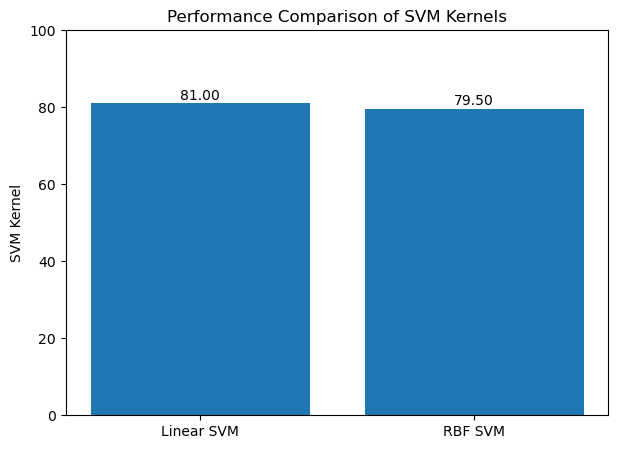

In [41]:
models = ['Linear SVM', 'RBF SVM']

accuracy = [linear_accuracy * 100, rbf_accuracy * 100]

plt.figure(figsize=(7,5))

bars = plt.bar(models,accuracy)

plt.ylabel("Accuracy (%)")
plt.ylabel("SVM Kernel")

plt.title("Performance Comparison of SVM Kernels")

plt.ylim(0,100)

for bar,value in zip(bars,accuracy):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.2f}",
        ha='center'
    )

plt.show()